**M37 Parte2**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# Carregando a base de dados
df = pd.read_feather('credit_scoring.ftr')
print(f'Base carregada com sucesso! Shape: {df.shape}')
df.head()

Base carregada com sucesso! Shape: (750000, 15)


,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau
0,2015-01-01,5733,F,N,N,0,Empresário,Médio,Solteiro,Casa,43,6.873973,1.0,2515.39,False
1,2015-01-01,727,F,S,S,0,Assalariado,Médio,Casado,Casa,35,4.526027,2.0,3180.19,False
2,2015-01-01,6374,F,N,N,2,Assalariado,Médio,Casado,Casa,31,0.243836,4.0,1582.29,False
3,2015-01-01,9566,F,N,N,0,Assalariado,Médio,Casado,Casa,54,12.772603,2.0,13721.17,False
4,2015-01-01,9502,F,S,N,0,Assalariado,Superior incompleto,Solteiro,Casa,31,8.432877,1.0,2891.08,False


**Amostragem**

In [ ]:
# Identificando os três últimos meses disponíveis na base
meses_ordenados = sorted(df['data_ref'].unique())
meses_oot = meses_ordenados[-3:]

print('Todos os meses disponíveis:')
for m in meses_ordenados:
    print(f'  {m}')

print(f'\nMeses selecionados como OOT (validação): {meses_oot}')

Todos os meses disponíveis:
  2015-01-01 00:00:00
  2015-02-01 00:00:00
  2015-03-01 00:00:00
  2015-04-01 00:00:00
  2015-05-01 00:00:00
  2015-06-01 00:00:00
  2015-07-01 00:00:00
  2015-08-01 00:00:00
  2015-09-01 00:00:00
  2015-10-01 00:00:00
  2015-11-01 00:00:00
  2015-12-01 00:00:00
  2016-01-01 00:00:00
  2016-02-01 00:00:00
  2016-03-01 00:00:00

Meses selecionados como OOT (validação): [Timestamp('2016-01-01 00:00:00'), Timestamp('2016-02-01 00:00:00'), Timestamp('2016-03-01 00:00:00')]


In [ ]:
# Separação treino / OOT
df_treino = df[~df['data_ref'].isin(meses_oot)].copy().reset_index(drop=True)
df_oot    = df[ df['data_ref'].isin(meses_oot)].copy().reset_index(drop=True)

print(f'Base de treino (desenvolvimento): {df_treino.shape[0]:,} registros')
print(f'Base OOT (validação out of time): {df_oot.shape[0]:,} registros')

Base de treino (desenvolvimento): 600,000 registros
Base OOT (validação out of time): 150,000 registros


**Análise Descritiva**

In [ ]:
# Visão geral da base
print(f'Número total de linhas: {df.shape[0]:,}')
print(f'Número de colunas: {df.shape[1]}')
print('\nDistribuição por safra (data_ref):')
dist_safra = df.groupby('data_ref').size().reset_index(name='qtd_registros')
print(dist_safra.to_string(index=False))

Número total de linhas: 750,000
Número de colunas: 15

Distribuição por safra (data_ref):
  data_ref  qtd_registros
2015-01-01          50000
2015-02-01          50000
2015-03-01          50000
2015-04-01          50000
2015-05-01          50000
2015-06-01          50000
2015-07-01          50000
2015-08-01          50000
2015-09-01          50000
2015-10-01          50000
2015-11-01          50000
2015-12-01          50000
2016-01-01          50000
2016-02-01          50000
2016-03-01          50000


In [ ]:
# Definindo os grupos de variáveis por natureza
cols_ignorar = ['data_ref', 'index', 'mau']

variaveis_categoricas = [
    'sexo', 'posse_de_imovel', 'posse_de_veiculo',
    'tipo_renda', 'educacao', 'estado_civil', 'tipo_residencia'
]
variaveis_numericas = [
    'qtd_filhos', 'idade', 'tempo_emprego',
    'qt_pessoas_residencia', 'renda'
]

print('Variáveis categóricas:', variaveis_categoricas)
print('Variáveis numéricas:', variaveis_numericas)

Variáveis categóricas: ['sexo', 'posse_de_imovel', 'posse_de_veiculo', 'tipo_renda', 'educacao', 'estado_civil', 'tipo_residencia']
Variáveis numéricas: ['qtd_filhos', 'idade', 'tempo_emprego', 'qt_pessoas_residencia', 'renda']


In [ ]:
# Estatísticas descritivas das variáveis numéricas
print('=== Descritiva das Variáveis Numéricas ===')
df[variaveis_numericas].describe().T

=== Descritiva das Variáveis Numéricas ===


,count,mean,std,min,25%,50%,75%,max
qtd_filhos,750000.0,0.433251,0.739379,0.000000,0.000000,0.000000,1.000000,1.400000e+01
idade,750000.0,43.804733,11.229868,22.000000,34.000000,43.000000,53.000000,6.800000e+01
tempo_emprego,624043.0,7.748574,6.687455,0.117808,3.049315,6.046575,10.183562,4.290685e+01
qt_pessoas_residencia,750000.0,2.212241,0.903428,1.000000,2.000000,2.000000,3.000000,1.500000e+01
renda,750000.0,23238.544747,79106.013795,107.670000,3467.700000,7861.820000,18318.280000,4.083986e+06


In [ ]:
# Frequências das variáveis categóricas
print('=== Descritiva das Variáveis Categóricas ===')
for col in variaveis_categoricas:
    print(f'\n--- {col} ---')
    freq = df[col].value_counts(dropna=False)
    pct  = df[col].value_counts(dropna=False, normalize=True).mul(100).round(2)
    print(pd.DataFrame({'contagem': freq, 'percentual (%)': pct}))

=== Descritiva das Variáveis Categóricas ===

--- sexo ---
      contagem  percentual (%)
sexo                          
F       504580           67.28
M       245420           32.72

--- posse_de_imovel ---
                 contagem  percentual (%)
posse_de_imovel                          
S                  503692           67.16
N                  246308           32.84

--- posse_de_veiculo ---
                  contagem  percentual (%)
posse_de_veiculo                          
N                   457954           61.06
S                   292046           38.94

--- tipo_renda ---
                  contagem  percentual (%)
tipo_renda                                
Assalariado         385740           51.43
Empresário          172712           23.03
Pensionista         126265           16.84
Servidor público     64922            8.66
Bolsista               361            0.05

--- educacao ---
                     contagem  percentual (%)
educacao                                 

In [ ]:
# Distribuição da variável-alvo
print('=== Distribuição da variável mau ===')
mau_dist = df['mau'].value_counts()
print(mau_dist)
print(f'\nTaxa de inadimplência: {mau_dist[1]/mau_dist.sum()*100:.2f}%')

=== Distribuição da variável mau ===
mau
False    691357
True      58643
Name: count, dtype: int64

Taxa de inadimplência: 7.82%


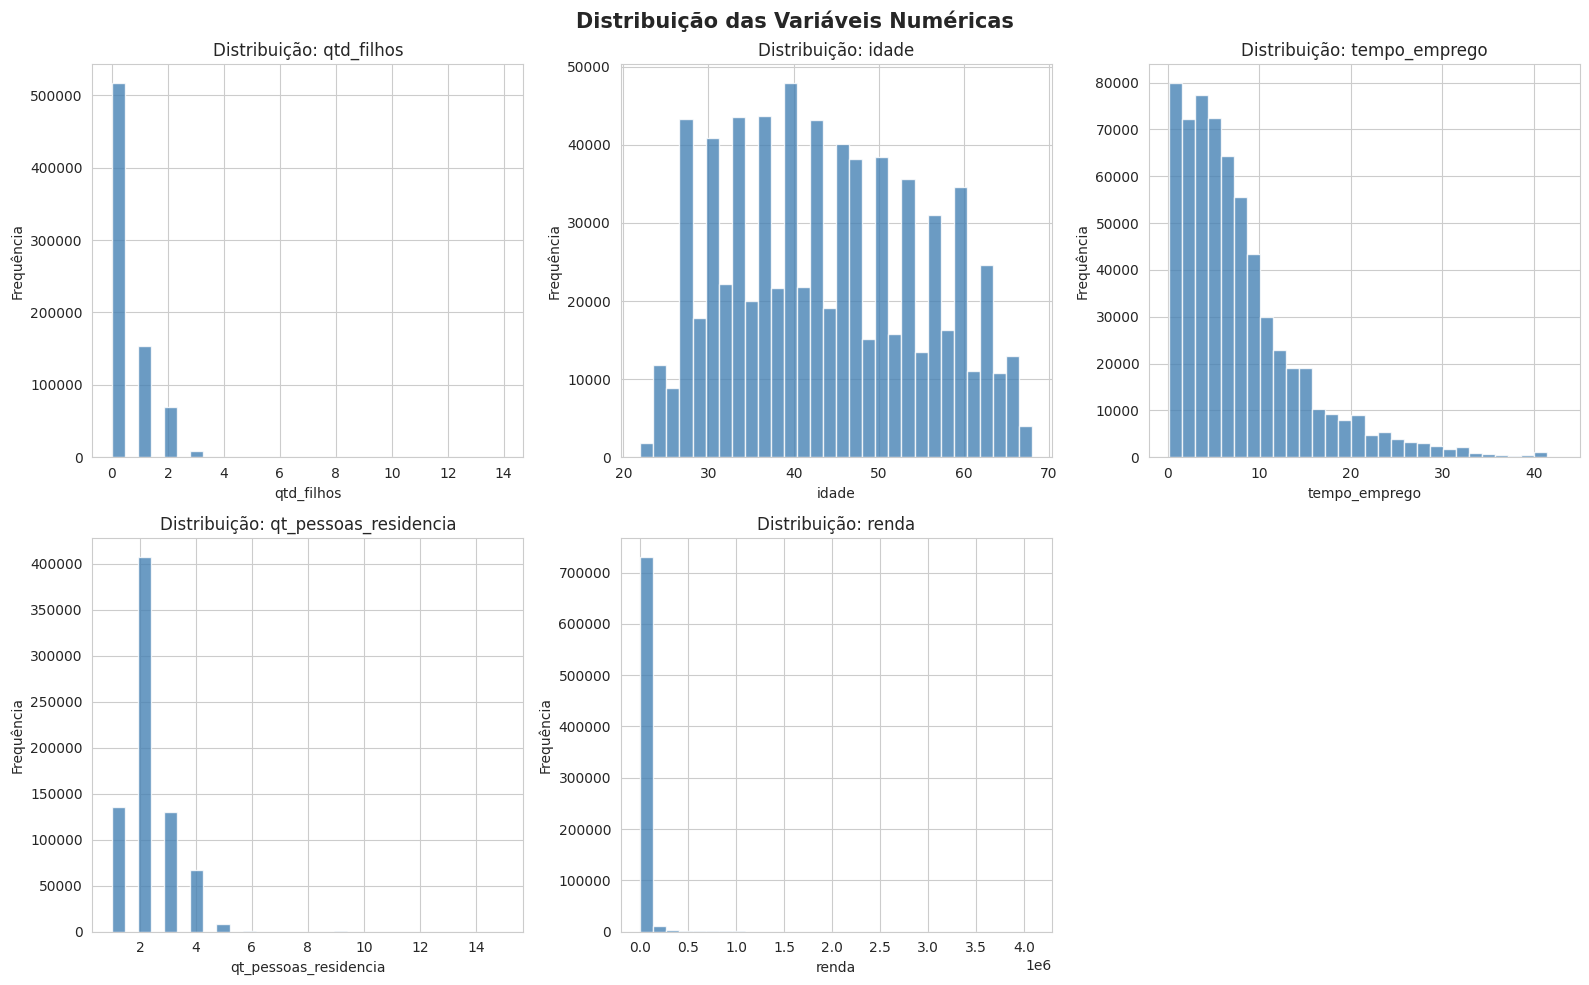

In [ ]:
# Visualização das variáveis numéricas — histogramas
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, var in enumerate(variaveis_numericas):
    axes[i].hist(df[var].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribuição: {var}', fontsize=12)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frequência')

# Ocultar subplot extra
axes[-1].set_visible(False)

fig.suptitle('Distribuição das Variáveis Numéricas', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

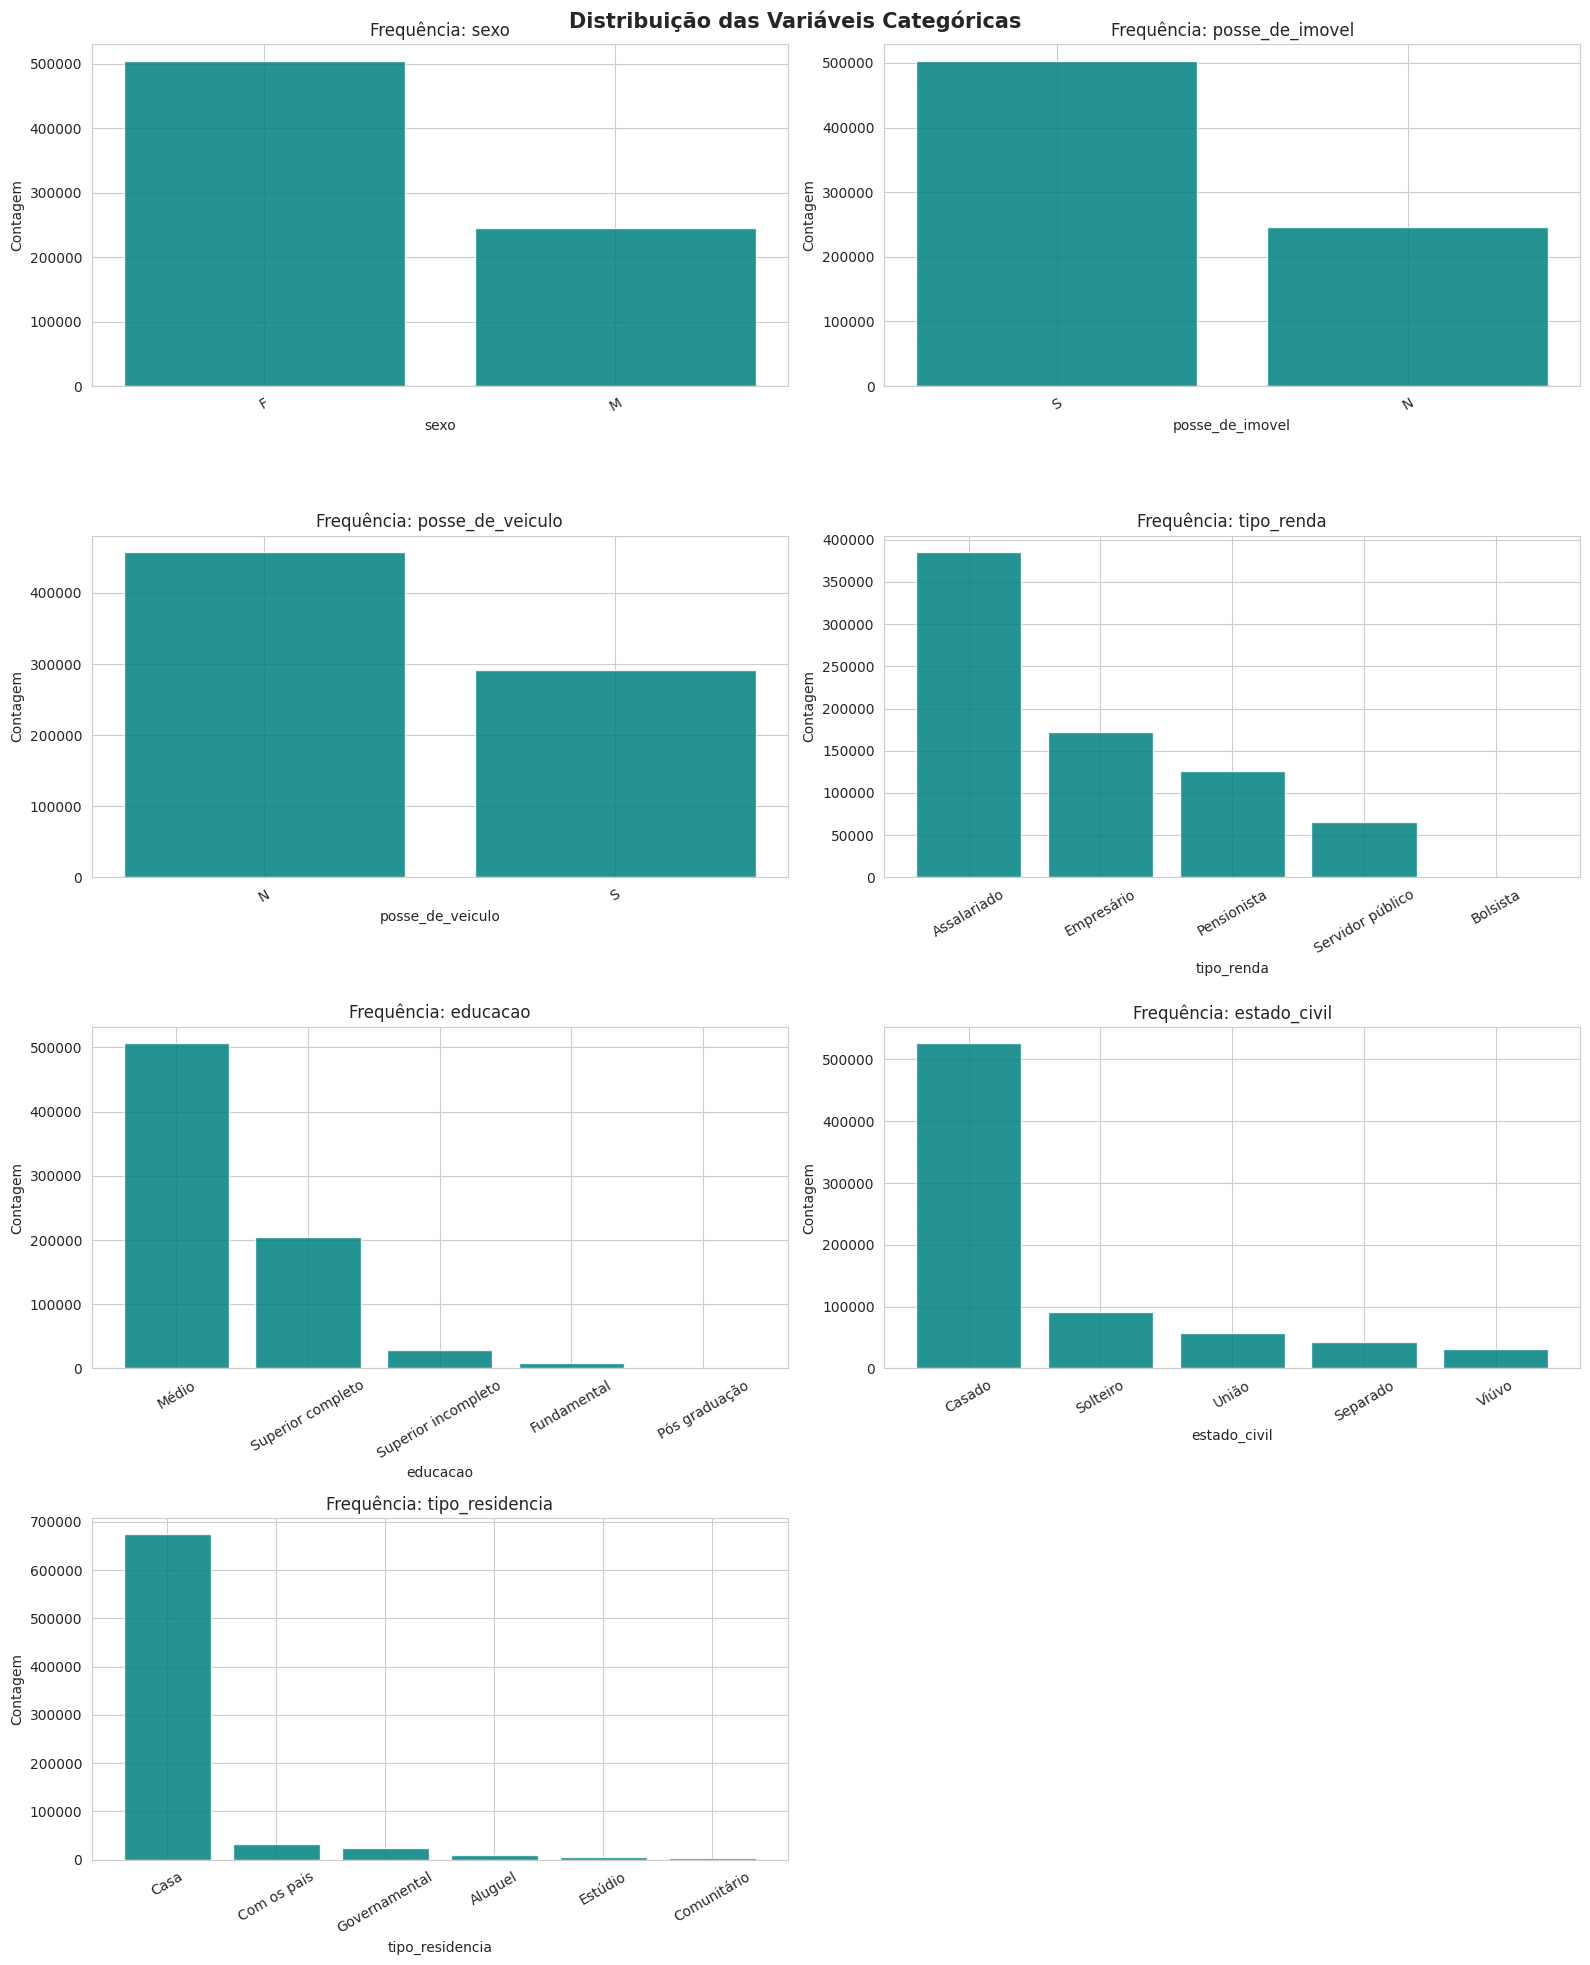

In [ ]:
# Visualização das variáveis categóricas — barras
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, var in enumerate(variaveis_categoricas):
    contagem = df[var].value_counts()
    axes[i].bar(contagem.index, contagem.values, color='teal', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Frequência: {var}', fontsize=12)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Contagem')
    axes[i].tick_params(axis='x', rotation=30)

# Ocultar o último subplot se sobrarem
for j in range(len(variaveis_categoricas), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribuição das Variáveis Categóricas', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**Análise Descritiva Bivariada**

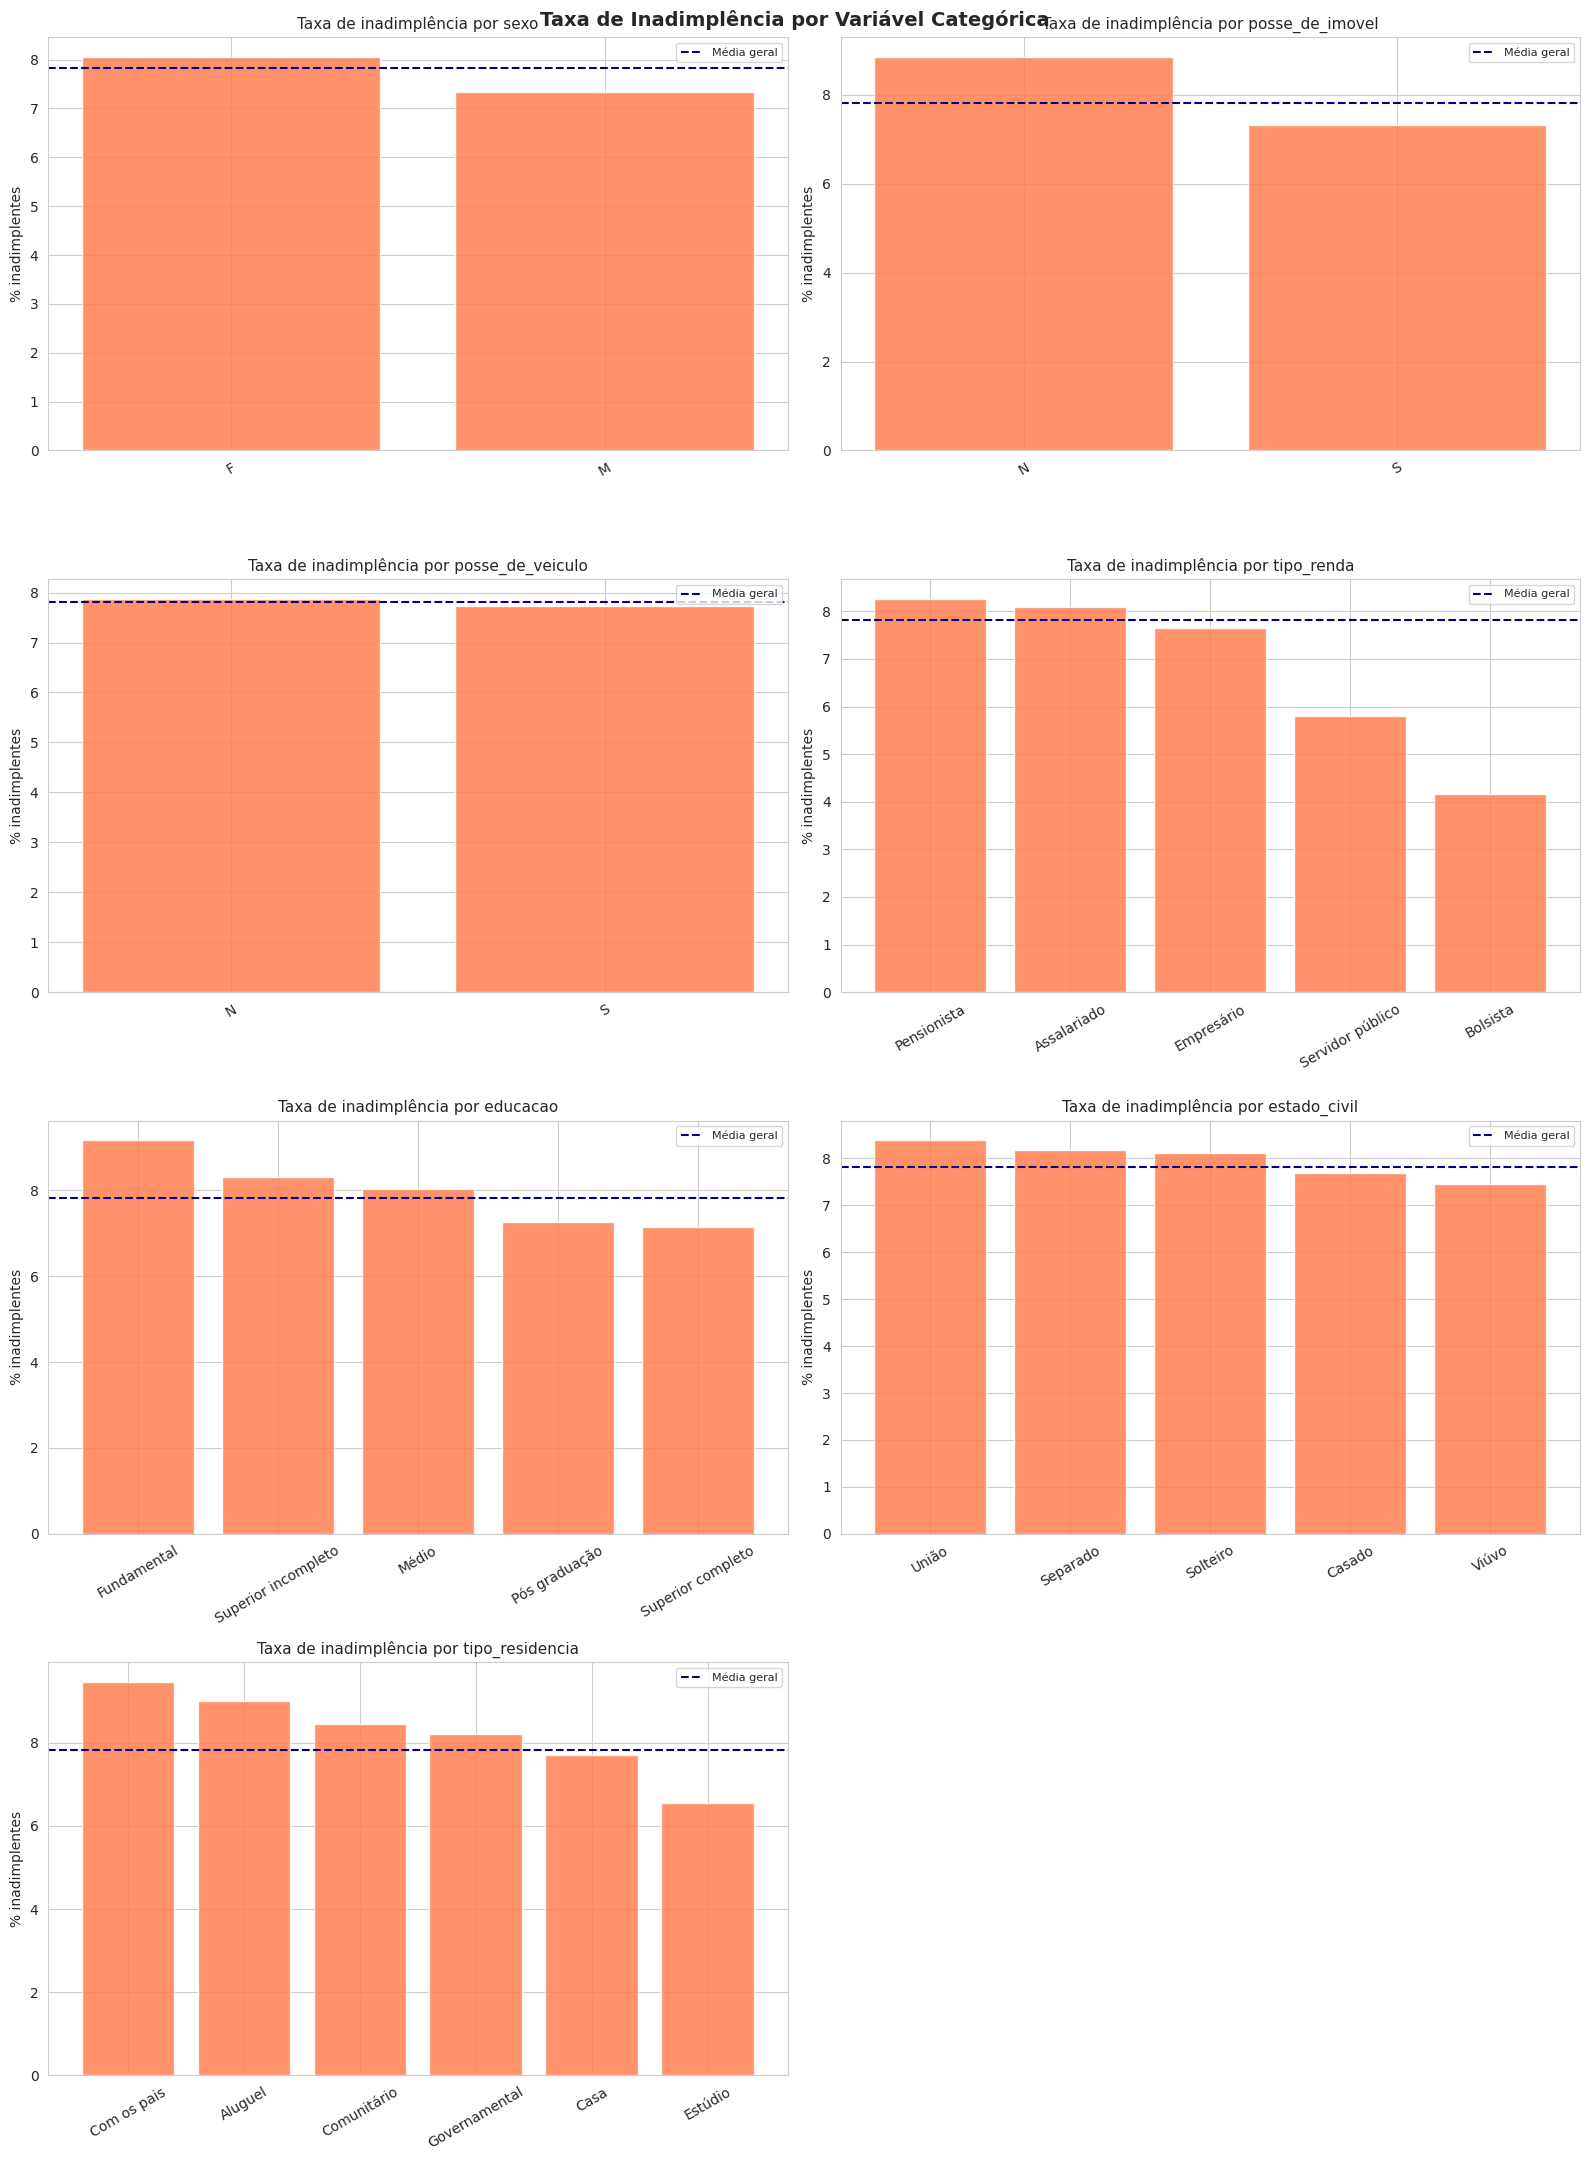

In [ ]:
# Bivariada: taxa de inadimplência por variável categórica
fig, axes = plt.subplots(4, 2, figsize=(16, 22))
axes = axes.flatten()

for i, var in enumerate(variaveis_categoricas):
    taxa_mau = df.groupby(var)['mau'].mean().sort_values(ascending=False)
    axes[i].bar(taxa_mau.index, taxa_mau.values * 100, color='coral', edgecolor='white', alpha=0.85)
    axes[i].axhline(df['mau'].mean() * 100, color='navy', linestyle='--', linewidth=1.5, label='Média geral')
    axes[i].set_title(f'Taxa de inadimplência por {var}', fontsize=11)
    axes[i].set_ylabel('% inadimplentes')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(fontsize=8)

for j in range(len(variaveis_categoricas), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Taxa de Inadimplência por Variável Categórica', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

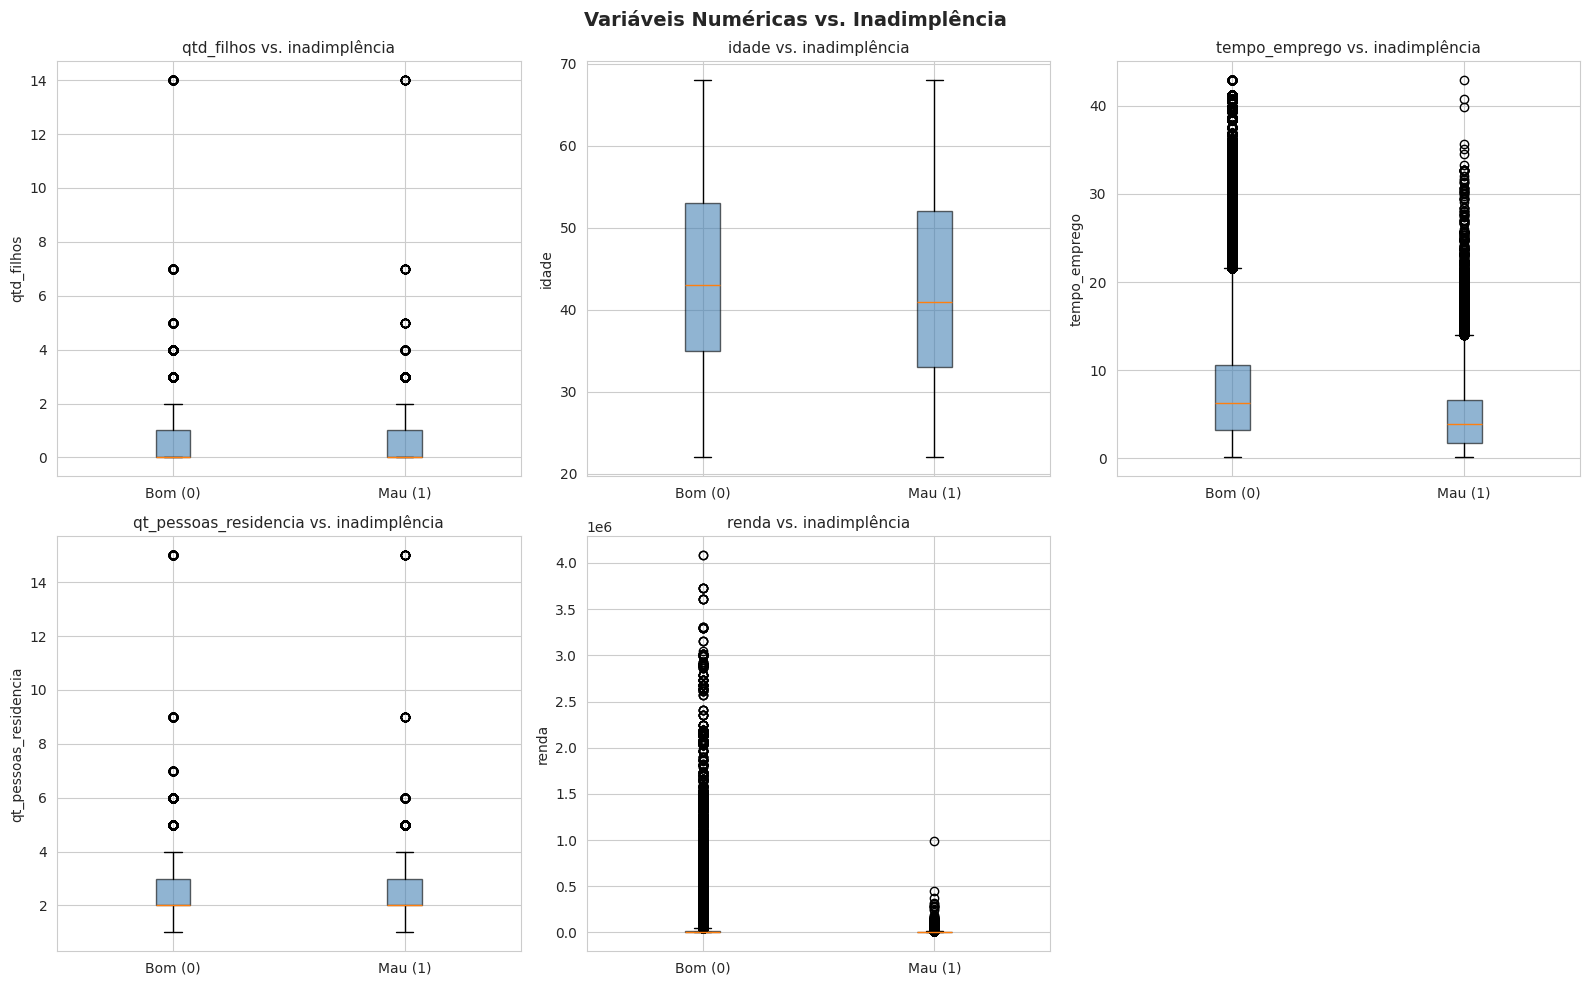

In [ ]:
# Bivariada: boxplot das variáveis numéricas x variável-alvo
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, var in enumerate(variaveis_numericas):
    data_bom = df.loc[df['mau'] == 0, var].dropna()
    data_mau = df.loc[df['mau'] == 1, var].dropna()
    axes[i].boxplot([data_bom, data_mau], labels=['Bom (0)', 'Mau (1)'],
                    patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(f'{var} vs. inadimplência', fontsize=11)
    axes[i].set_ylabel(var)

axes[-1].set_visible(False)

fig.suptitle('Variáveis Numéricas vs. Inadimplência', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Desenvolvimento do modelo

In [ ]:
# --- Trabalhando em cópia da base ---
df_modelo = df.copy()

# 1. Remover variáveis sem discriminação
df_modelo = df_modelo.drop(columns=['posse_de_veiculo', 'data_ref', 'index'])

# 2. Agrupar qtd_filhos
df_modelo['qtd_filhos'] = df_modelo['qtd_filhos'].apply(lambda x: '6+' if x > 5 else str(int(x)))

# 3. Remover categorias escassas em tipo_renda
df_modelo = df_modelo[~df_modelo['tipo_renda'].isin(['Pensionista', 'Bolsista'])]

# 4. Unificar pós-graduação com superior
df_modelo['educacao'] = df_modelo['educacao'].replace('Pós graduação', 'Superior completo')

# 5. Tratar valores negativos em tempo_emprego (zeros estruturais: desempregados)
df_modelo['tempo_emprego'] = df_modelo['tempo_emprego'].clip(lower=0)

# 6. Imputar missings
for col in df_modelo.select_dtypes(include='number').columns:
    df_modelo[col] = df_modelo[col].fillna(df_modelo[col].median())

for col in df_modelo.select_dtypes(include='object').columns:
    df_modelo[col] = df_modelo[col].fillna(df_modelo[col].mode()[0])

print(f'Base após pré-processamento: {df_modelo.shape}')
print('Missings restantes:', df_modelo.isna().sum().sum())

Base após pré-processamento: (623374, 12)
Missings restantes: 0


In [ ]:
# Verificar colunas finais
print('Colunas do modelo:')
print(df_modelo.columns.tolist())

Colunas do modelo:
['sexo', 'posse_de_imovel', 'qtd_filhos', 'tipo_renda', 'educacao', 'estado_civil', 'tipo_residencia', 'idade', 'tempo_emprego', 'qt_pessoas_residencia', 'renda', 'mau']


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Separar alvo e preditoras
X = df_modelo.drop(columns=['mau'])
y = df_modelo['mau']

# Codificação das variáveis categóricas com pd.get_dummies (one-hot)
X = pd.get_dummies(X, drop_first=True)

print(f'Dimensões de X após encoding: {X.shape}')

Dimensões de X após encoding: (623374, 26)


In [ ]:
# Separação treino / OOT aplicando os mesmos filtros
df_oot_modelo = df_oot.copy()
df_oot_modelo = df_oot_modelo.drop(columns=['posse_de_veiculo', 'data_ref', 'index'], errors='ignore')
df_oot_modelo = df_oot_modelo[~df_oot_modelo['tipo_renda'].isin(['Pensionista', 'Bolsista'])]
df_oot_modelo['educacao'] = df_oot_modelo['educacao'].replace('Pós graduação', 'Superior completo')
df_oot_modelo['qtd_filhos'] = df_oot_modelo['qtd_filhos'].apply(lambda x: '6+' if x > 5 else str(int(x)))
df_oot_modelo['tempo_emprego'] = df_oot_modelo['tempo_emprego'].clip(lower=0)

for col in df_oot_modelo.select_dtypes(include='number').columns:
    df_oot_modelo[col] = df_oot_modelo[col].fillna(df_oot_modelo[col].median())

for col in df_oot_modelo.select_dtypes(include='object').columns:
    df_oot_modelo[col] = df_oot_modelo[col].fillna(df_oot_modelo[col].mode()[0])

X_oot = df_oot_modelo.drop(columns=['mau'])
y_oot = df_oot_modelo['mau']
X_oot = pd.get_dummies(X_oot, drop_first=True)

# Alinhar colunas entre treino e OOT
X_oot = X_oot.reindex(columns=X.columns, fill_value=0)

print(f'Base treino: {X.shape}  |  Base OOT: {X_oot.shape}')

Base treino: (623374, 26)  |  Base OOT: (124792, 26)


Treinamento de Modelo Regressão Logística

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Pipeline: padronização + regressão logística
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

pipeline.fit(X, y)
print('Modelo treinado com sucesso!')

Modelo treinado com sucesso!


In [ ]:
# Coeficientes do modelo
coef_df = pd.DataFrame({
    'variavel': X.columns,
    'coeficiente': pipeline.named_steps['logreg'].coef_[0]
}).sort_values('coeficiente', ascending=False)

print('=== Coeficientes do modelo (ordenados) ===')
coef_df

=== Coeficientes do modelo (ordenados) ===


,variavel,coeficiente
8,qtd_filhos_3,0.009046
11,qtd_filhos_6+,0.007698
19,estado_civil_União,0.006744
6,qtd_filhos_1,0.006383
10,qtd_filhos_5,0.006074
7,qtd_filhos_2,0.005881
18,estado_civil_Solteiro,0.000912
17,estado_civil_Separado,-0.001451
0,idade,-0.002636
24,tipo_residencia_Estúdio,-0.005037


Avaliação do Modelo

In [ ]:
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

def ks_gini(y_true, y_prob):
    """Calcula KS e Gini a partir das probabilidades preditas."""
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ks = float(np.max(tpr - fpr))
    auc = roc_auc_score(y_true, y_prob)
    gini = 2 * auc - 1
    return ks, gini, auc

# Predições
y_prob_dev = pipeline.predict_proba(X)[:, 1]
y_prob_oot = pipeline.predict_proba(X_oot)[:, 1]

y_pred_dev = (y_prob_dev >= 0.5).astype(int)
y_pred_oot = (y_prob_oot >= 0.5).astype(int)

# Métricas
ks_dev,  gini_dev,  auc_dev  = ks_gini(y, y_prob_dev)
ks_oot,  gini_oot,  auc_oot  = ks_gini(y_oot, y_prob_oot)

acc_dev = accuracy_score(y, y_pred_dev)
acc_oot = accuracy_score(y_oot, y_pred_oot)

print('========================================')
print('       AVALIAÇÃO DO MODELO')
print('========================================')
print(f"{'Métrica':<12} {'Desenvolvimento':>18} {'OOT (Validação)':>18}")
print('-' * 50)
print(f"{'Acurácia':<12} {acc_dev:>18.4f} {acc_oot:>18.4f}")
print(f"{'KS':<12} {ks_dev:>18.4f} {ks_oot:>18.4f}")
print(f"{'Gini':<12} {gini_dev:>18.4f} {gini_oot:>18.4f}")
print(f"{'AUC-ROC':<12} {auc_dev:>18.4f} {auc_oot:>18.4f}")

       AVALIAÇÃO DO MODELO
Métrica         Desenvolvimento    OOT (Validação)
--------------------------------------------------
Acurácia                 0.5662             0.3721
KS                       0.4200             0.3331
Gini                     0.5569             0.4569
AUC-ROC                  0.7785             0.7284


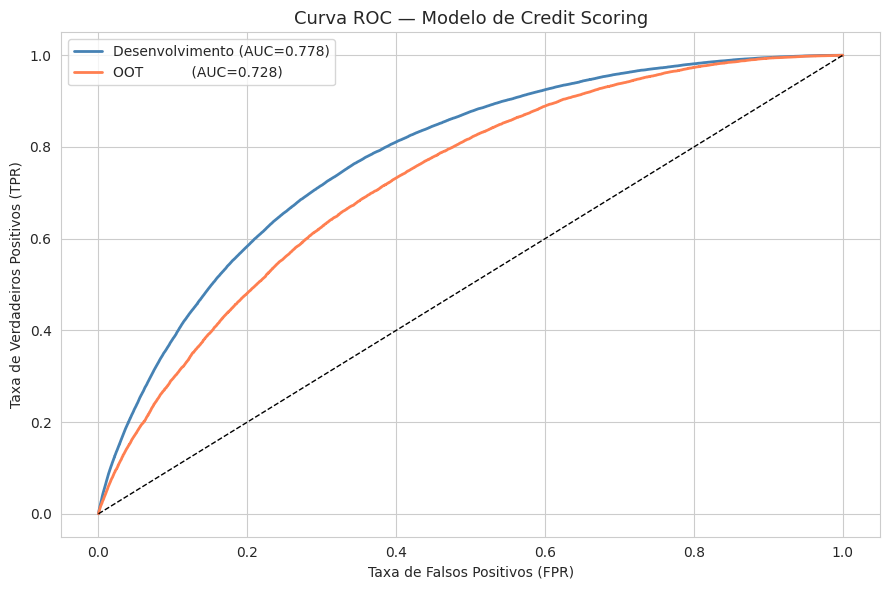

In [ ]:
# Curva ROC — Desenvolvimento vs OOT
fpr_dev, tpr_dev, _ = roc_curve(y, y_prob_dev)
fpr_oot, tpr_oot, _ = roc_curve(y_oot, y_prob_oot)

plt.figure(figsize=(9, 6))
plt.plot(fpr_dev, tpr_dev, color='steelblue',  lw=2, label=f'Desenvolvimento (AUC={auc_dev:.3f})')
plt.plot(fpr_oot, tpr_oot, color='coral',      lw=2, label=f'OOT           (AUC={auc_oot:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC — Modelo de Credit Scoring', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

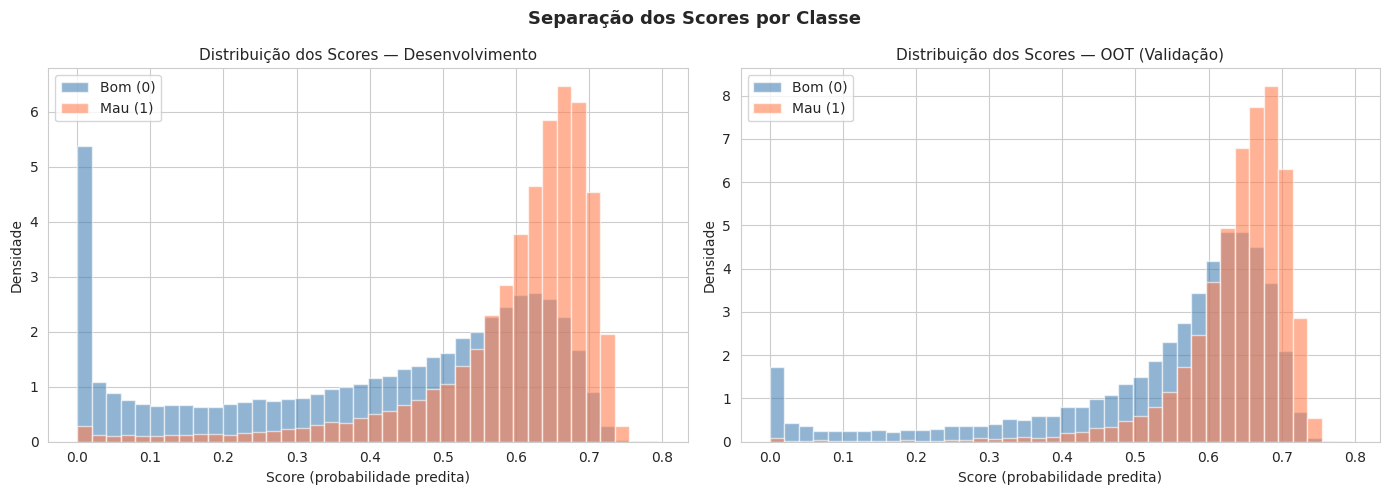

In [ ]:
# Distribuição dos scores por classe — KS visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (y_true, y_prob, titulo) in zip(axes, [
    (y, y_prob_dev, 'Desenvolvimento'),
    (y_oot, y_prob_oot, 'OOT (Validação)')
]):
    bom = y_prob[y_true == 0]
    mau_score = y_prob[y_true == 1]
    ax.hist(bom, bins=40, alpha=0.6, color='steelblue', label='Bom (0)', density=True)
    ax.hist(mau_score, bins=40, alpha=0.6, color='coral', label='Mau (1)', density=True)
    ax.set_title(f'Distribuição dos Scores — {titulo}', fontsize=11)
    ax.set_xlabel('Score (probabilidade predita)')
    ax.set_ylabel('Densidade')
    ax.legend()

plt.suptitle('Separação dos Scores por Classe', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
#Importando Bibliotecas
import sys
import subprocess
import importlib.util
import warnings
warnings.filterwarnings("ignore")

# Garante suporte a arquivos .ftr/.feather
if importlib.util.find_spec("pyarrow") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pyarrow"])

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

# Caminhos possíveis no Colab/Jupyter
caminhos_possiveis = [
    "credit_scoring.ftr",
    "/content/credit_scoring.ftr",
    "../Dados/credit_scoring.ftr",
    "/mnt/data/credit_scoring.ftr"
]

arquivo = None
for caminho in caminhos_possiveis:
    if os.path.exists(caminho):
        arquivo = caminho
        break

# Caso esteja no Colab e o arquivo ainda não tenha sido enviado
if arquivo is None:
    try:
        from google.colab import files
        print("Envie o arquivo credit_scoring.ftr")
        uploaded = files.upload()
        arquivo = list(uploaded.keys())[0]
    except Exception as e:
        raise FileNotFoundError(
            "Não encontrei o arquivo credit_scoring.ftr. "
            "Faça upload dele no Colab ou ajuste o caminho."
        ) from e

# Leitura do arquivo.
# O caminho normal é pd.read_feather. O fallback com pyarrow evita incompatibilidades
# pontuais de versão entre pandas e pyarrow em alguns ambientes.
try:
    df = pd.read_feather(arquivo)
except Exception:
    import pyarrow.feather as feather
    df = feather.read_table(arquivo).to_pandas(ignore_metadata=True)

# Ajustes básicos
df["data_ref"] = pd.to_datetime(df["data_ref"])
df["mau"] = df["mau"].astype(int)

print(f"Base carregada: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
print(f"Arquivo usado: {arquivo}")
display(df.head())


Base carregada: 750,000 linhas × 15 colunas
Arquivo usado: credit_scoring.ftr


,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau
0,2015-01-01,5733,F,N,N,0,Empresário,Médio,Solteiro,Casa,43,6.873973,1.0,2515.39,0
1,2015-01-01,727,F,S,S,0,Assalariado,Médio,Casado,Casa,35,4.526027,2.0,3180.19,0
2,2015-01-01,6374,F,N,N,2,Assalariado,Médio,Casado,Casa,31,0.243836,4.0,1582.29,0
3,2015-01-01,9566,F,N,N,0,Assalariado,Médio,Casado,Casa,54,12.772603,2.0,13721.17,0
4,2015-01-01,9502,F,S,N,0,Assalariado,Superior incompleto,Solteiro,Casa,31,8.432877,1.0,2891.08,0


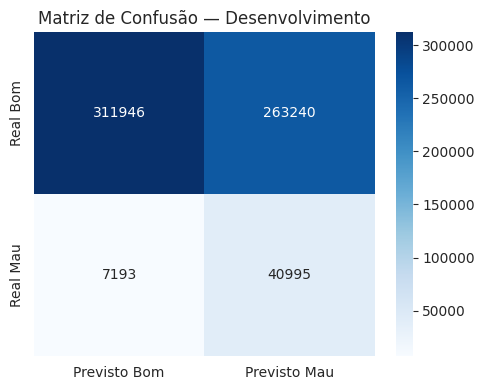


=== Relatório de Classificação — Desenvolvimento ===
              precision    recall  f1-score   support

       False       0.98      0.54      0.70    575186
        True       0.13      0.85      0.23     48188

    accuracy                           0.57    623374
   macro avg       0.56      0.70      0.47    623374
weighted avg       0.91      0.57      0.66    623374



In [ ]:
# Matriz de confusão — Base de desenvolvimento
cm = confusion_matrix(y, y_pred_dev)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Previsto Bom', 'Previsto Mau'],
            yticklabels=['Real Bom', 'Real Mau'])
plt.title('Matriz de Confusão — Desenvolvimento')
plt.tight_layout()
plt.show()

print('\n=== Relatório de Classificação — Desenvolvimento ===')
print(classification_report(y, y_pred_dev))

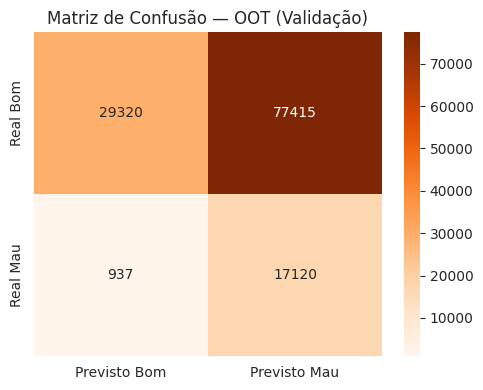


=== Relatório de Classificação — OOT ===
              precision    recall  f1-score   support

       False       0.97      0.27      0.43    106735
        True       0.18      0.95      0.30     18057

    accuracy                           0.37    124792
   macro avg       0.58      0.61      0.37    124792
weighted avg       0.86      0.37      0.41    124792



In [ ]:
# Matriz de confusão — Base OOT
cm_oot = confusion_matrix(y_oot, y_pred_oot)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_oot, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Previsto Bom', 'Previsto Mau'],
            yticklabels=['Real Bom', 'Real Mau'])
plt.title('Matriz de Confusão — OOT (Validação)')
plt.tight_layout()
plt.show()

print('\n=== Relatório de Classificação — OOT ===')
print(classification_report(y_oot, y_pred_oot))

**Conclusão**


O modelo de regressão logística desenvolvido nesta tarefa demonstrou desempenho satisfatório para o problema de credit scoring em cartão de crédito.

Principais achados:

- A análise descritiva bivariada indicou que variáveis como **tempo de emprego**, **renda**, **tipo de renda** e **estado civil** possuem boa relação com o risco de inadimplência.

- A variável posse de veiculo apresentou pouca discriminação e foi removida do modelo.

- O modelo obteve métricas consistentes tanto na base de **desenvolvimento** quanto na base **OOT**, indicando boa capacidade de generalização — o que é fundamental em credit scoring.

- O **KS** e o **Gini** ficaram dentro de faixas aceitáveis para modelos desta natureza, confirmando o poder discriminante do modelo.

Próximos passos sugeridos:
- Realizar **seleção de variáveis** com Information Value (IV) e WoE
- Testar regularização com C ajustado via validação cruzada
- Explorar técnicas de **balanceamento de classes** (SMOTE, undersampling)
